In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
data = pd.read_csv('cleaned_data.csv')

In [3]:
data.sample(2)

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
102650,39,0.109783,0,0,0,1.512488,0,1000.0,4,1,4.0,0
94655,60,0.088587,1,0,0,0.357791,0,6500.0,12,1,0.0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134206 entries, 0 to 134205
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   134206 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  134206 non-null  float64
 2   NumberOfTime30-59DaysPastDueNotWorse  134206 non-null  int64  
 3   NumberOfTime60-89DaysPastDueNotWorse  134206 non-null  int64  
 4   NumberOfTimes90DaysLate               134206 non-null  int64  
 5   DebtRatio                             134206 non-null  float64
 6   DebtRatioMissing                      134206 non-null  int64  
 7   MonthlyIncome                         134206 non-null  float64
 8   NumberOfOpenCreditLinesAndLoans       134206 non-null  int64  
 9   NumberRealEstateLoansOrLines          134206 non-null  int64  
 10  NumberOfDependents                    134206 non-null  float64
 11  

In [5]:
df = data.copy()

In [6]:
df.columns

Index(['age', 'RevolvingUtilizationOfUnsecuredLines',
       'NumberOfTime30-59DaysPastDueNotWorse',
       'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
       'DebtRatio', 'DebtRatioMissing', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines',
       'NumberOfDependents', 'SeriousDlqin2yrs'],
      dtype='object')

# Deliquency analysis

<Axes: xlabel='NumberOfTime30-59DaysPastDueNotWorse', ylabel='count'>

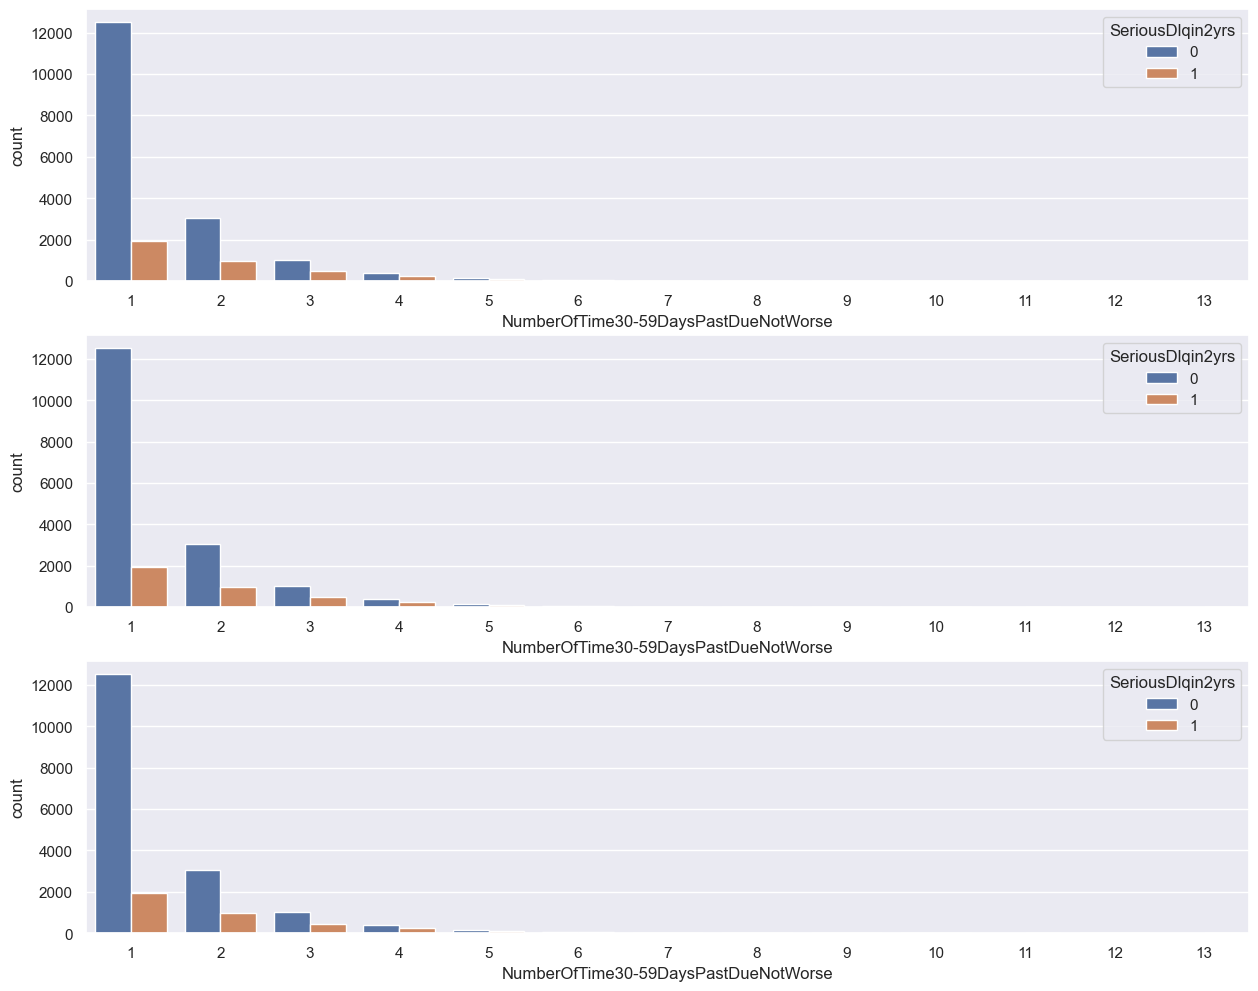

In [7]:
plt.figure(figsize=(15,12))

plt.subplot(3,1,1)
sns.countplot(x='NumberOfTime30-59DaysPastDueNotWorse',data = df[df['NumberOfTime30-59DaysPastDueNotWorse']>0],hue='SeriousDlqin2yrs')

plt.subplot(3,1,2)
sns.countplot(x='NumberOfTime30-59DaysPastDueNotWorse',data = df[df['NumberOfTime30-59DaysPastDueNotWorse']>0],hue='SeriousDlqin2yrs')

plt.subplot(3,1,3)
sns.countplot(x='NumberOfTime30-59DaysPastDueNotWorse',data = df[df['NumberOfTime30-59DaysPastDueNotWorse']>0],hue='SeriousDlqin2yrs')

This does not give a great insight. Thus, we will make 3 columns. Where, if deliquent then column will have value 0, or else 1

In [8]:
df['30-59DaysLate'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] != 0).astype(int)
df['60-89DaysLate'] = (df['NumberOfTime60-89DaysPastDueNotWorse'] != 0).astype(int)
df['90DaysLate'] = (df['NumberOfTimes90DaysLate'] != 0).astype(int)

We will drop the original columns only for visualization part

In [9]:
df.drop(['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate'],axis=1,inplace=True)

In [10]:
df.columns

Index(['age', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio',
       'DebtRatioMissing', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents',
       'SeriousDlqin2yrs', '30-59DaysLate', '60-89DaysLate', '90DaysLate'],
      dtype='object')

In [11]:
df = df[['age', 'RevolvingUtilizationOfUnsecuredLines','30-59DaysLate', '60-89DaysLate', '90DaysLate','DebtRatio',
       'DebtRatioMissing', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents',
       'SeriousDlqin2yrs']]

In [12]:
df

,age,RevolvingUtilizationOfUnsecuredLines,30-59DaysLate,60-89DaysLate,90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
0,45,0.766127,1,0,0,0.802982,0,9120.0,13,6,2.0,1
1,40,0.957151,0,0,0,0.121876,0,2600.0,4,0,1.0,0
2,38,0.658180,1,0,1,0.085113,0,3042.0,2,0,0.0,0
3,30,0.233810,0,0,0,0.036050,0,3300.0,5,0,0.0,0
4,49,0.907239,1,0,0,0.024926,0,63588.0,7,1,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
134201,74,0.040674,0,0,0,0.225131,0,2100.0,4,1,0.0,0
134202,44,0.299745,0,0,0,0.716562,0,5584.0,4,1,2.0,0
134203,58,0.246044,0,0,0,0.291184,1,3870.0,18,1,0.0,0
134204,30,0.000000,0,0,0,0.000000,0,5716.0,4,0,0.0,0


<Axes: xlabel='90DaysLate', ylabel='count'>

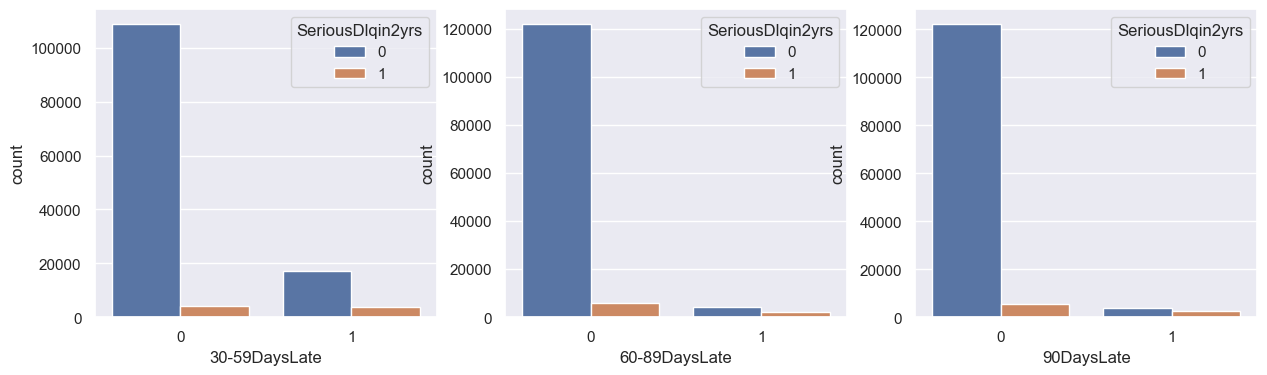

In [13]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.countplot(x='30-59DaysLate',data = df,hue='SeriousDlqin2yrs')

plt.subplot(1,3,2)
sns.countplot(x='60-89DaysLate',data = df,hue='SeriousDlqin2yrs')

plt.subplot(1,3,3)
sns.countplot(x='90DaysLate',data = df,hue='SeriousDlqin2yrs')

In [14]:
df.groupby('30-59DaysLate')['SeriousDlqin2yrs'].value_counts(normalize=True)

30-59DaysLate  SeriousDlqin2yrs
0              0                   0.962642
               1                   0.037358
1              0                   0.819829
               1                   0.180171
Name: proportion, dtype: float64

In [15]:
df.groupby('60-89DaysLate')['SeriousDlqin2yrs'].value_counts(normalize=True)

60-89DaysLate  SeriousDlqin2yrs
0              0                   0.952815
               1                   0.047185
1              0                   0.675342
               1                   0.324658
Name: proportion, dtype: float64

In [16]:
df.groupby('90DaysLate')['SeriousDlqin2yrs'].value_counts(normalize=True)

90DaysLate  SeriousDlqin2yrs
0           0                   0.956580
            1                   0.043420
1           0                   0.614917
            1                   0.385083
Name: proportion, dtype: float64

You'll observe that SeriousDlqin2yrs increases from 30-59DaysLate to 90DaysLate (0.41, 0.35, and 0.2)

**1st Observation) There is a higher chance of SeriousDeliquency by People who were 90DaysLate, followed by 60-89 Days, and then 30-59 Days**

# Age analysis

<Axes: xlabel='age', ylabel='Count'>

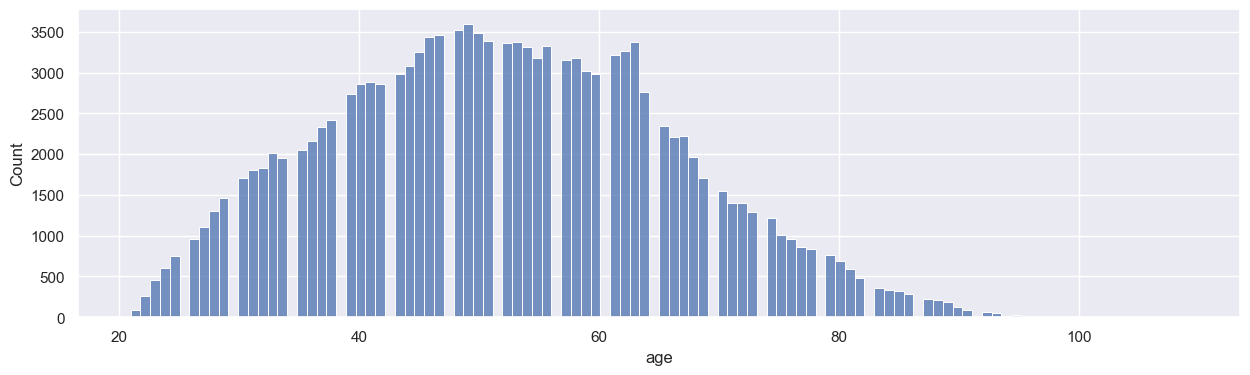

In [17]:
plt.figure(figsize=(15,4))
sns.histplot(df['age'])

In [18]:
df['age'].describe()

count    134206.000000
mean         51.978853
std          14.183685
min          21.000000
25%          41.000000
50%          52.000000
75%          62.000000
max         109.000000
Name: age, dtype: float64

We will make an age group column, with 4 categories

In [19]:
bins = [19, 35, 50, 65, float('inf')]
labels = ['Young', 'Middle-aged', 'Senior', 'Old']

df['AgeGroup'] = pd.cut(df['age'],bins=bins,labels=labels)

<Axes: title={'center': 'AgeGroup and SeriousDlq Rate'}, xlabel='AgeGroup', ylabel='count'>

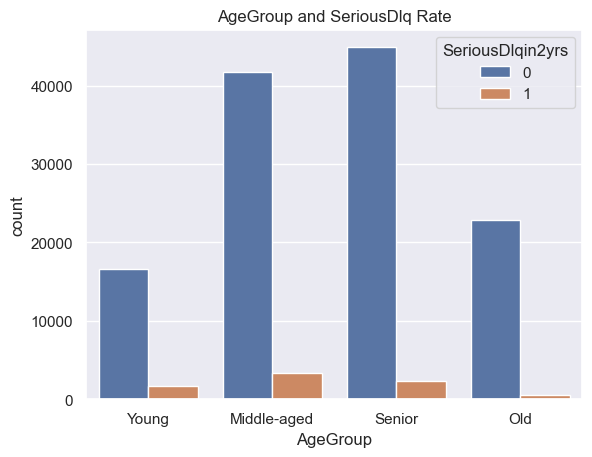

In [20]:
plt.title('AgeGroup and SeriousDlq Rate')
sns.countplot(x='AgeGroup',data=df,hue='SeriousDlqin2yrs')

In [21]:
df.groupby('AgeGroup')['SeriousDlqin2yrs'].value_counts(normalize=True)

C:\Users\bhavy\AppData\Local\Temp\ipykernel_916\2527660964.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['SeriousDlqin2yrs'].value_counts(normalize=True)


AgeGroup     SeriousDlqin2yrs
Young        0                   0.905915
             1                   0.094085
Middle-aged  0                   0.925470
             1                   0.074530
Senior       0                   0.950330
             1                   0.049670
Old          0                   0.975299
             1                   0.024701
Name: proportion, dtype: float64

Deliquency rate is almost the same for Young and Middle-aged people, and is very less for seniors and old people

<Axes: title={'center': 'Average Income in each Age Group'}, xlabel='AgeGroup', ylabel='MonthlyIncome'>

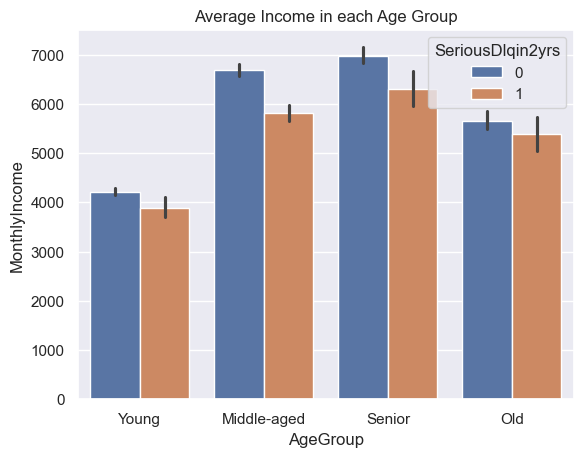

In [22]:
plt.title('Average Income in each Age Group')
sns.barplot(x='AgeGroup',y='MonthlyIncome',data=df,hue='SeriousDlqin2yrs')

In [23]:
df.groupby(['AgeGroup','SeriousDlqin2yrs'])['MonthlyIncome'].mean()

C:\Users\bhavy\AppData\Local\Temp\ipykernel_916\1584705162.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['AgeGroup','SeriousDlqin2yrs'])['MonthlyIncome'].mean()


AgeGroup     SeriousDlqin2yrs
Young        0                   4216.261623
             1                   3892.623482
Middle-aged  0                   6677.274614
             1                   5823.980661
Senior       0                   6973.115076
             1                   6293.890072
Old          0                   5643.383761
             1                   5383.367241
Name: MonthlyIncome, dtype: float64

<Axes: title={'center': 'DebtRatio in each Age Group'}, xlabel='AgeGroup', ylabel='DebtRatio'>

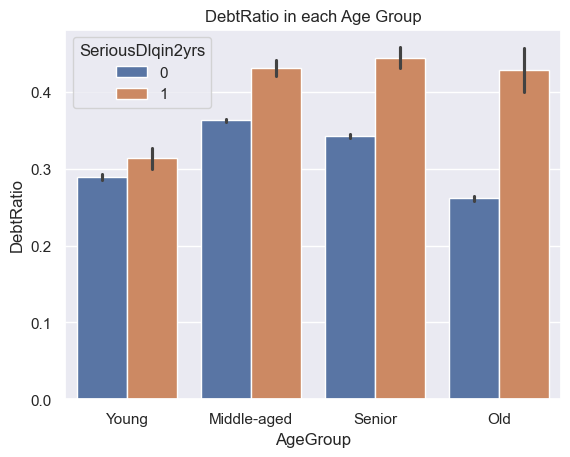

In [24]:
plt.title('DebtRatio in each Age Group')
sns.barplot(x='AgeGroup',y='DebtRatio',data=df,hue='SeriousDlqin2yrs')

In [25]:
df.groupby(['AgeGroup','SeriousDlqin2yrs'])['DebtRatio'].mean()

C:\Users\bhavy\AppData\Local\Temp\ipykernel_916\2860102828.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['AgeGroup','SeriousDlqin2yrs'])['DebtRatio'].mean()


AgeGroup     SeriousDlqin2yrs
Young        0                   0.288862
             1                   0.313621
Middle-aged  0                   0.363006
             1                   0.430704
Senior       0                   0.342442
             1                   0.443793
Old          0                   0.261612
             1                   0.428646
Name: DebtRatio, dtype: float64

Deliquents have a lower income and a higher debt ratio in each age group

Also, average monthly income and debt ratio is highest for middle aged and seniors. Both increases with age


**2nd Observation) Age group alone does not help you decide credit risk. It mainly depends on Income and DebtRatio. Lookout for people having DebtRatio more than 0.4. Younger people are more likely to deliquent with a lower DebtRatio** 

<Axes: xlabel='AgeGroup', ylabel='RevolvingUtilizationOfUnsecuredLines'>

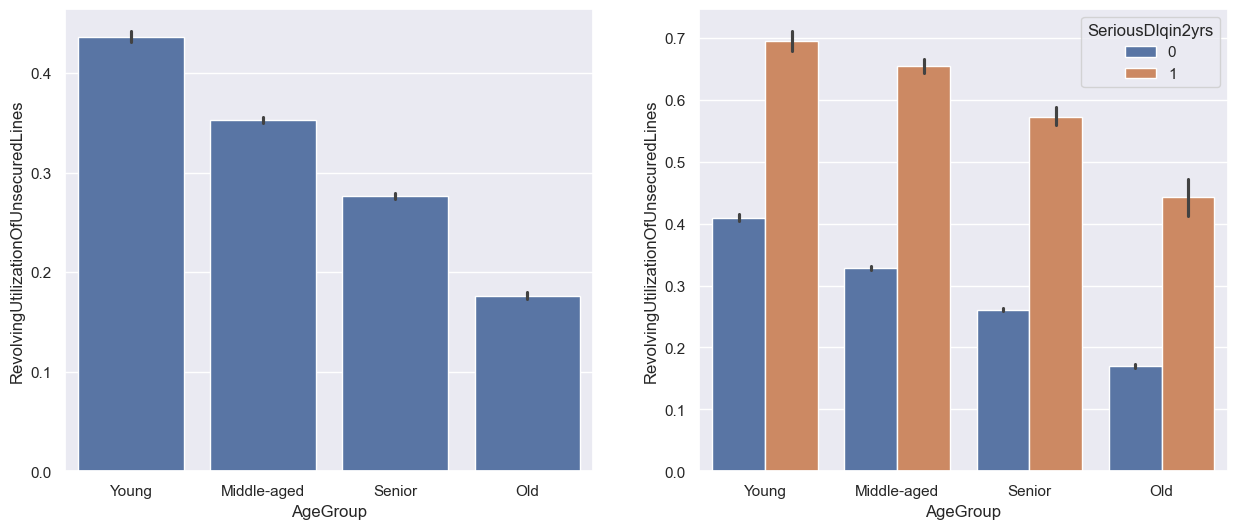

In [26]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.barplot(x='AgeGroup',y='RevolvingUtilizationOfUnsecuredLines',data=df)
plt.subplot(1,2,2)
sns.barplot(x='AgeGroup',y='RevolvingUtilizationOfUnsecuredLines',data=df,hue='SeriousDlqin2yrs')

Serious Deliquents in all age group have a higher Revolving Utilization. Even the lowest utilization rate in deliquents is higher than highest utilization rate in non-deliquents

**3rd observation) Look out for people having a high Revolving Utilization rate, typically more than 0.5**

**Also that the revolving utilization is highest in Young people, and it keeps on decreasing with age**

<Axes: xlabel='AgeGroup', ylabel='count'>

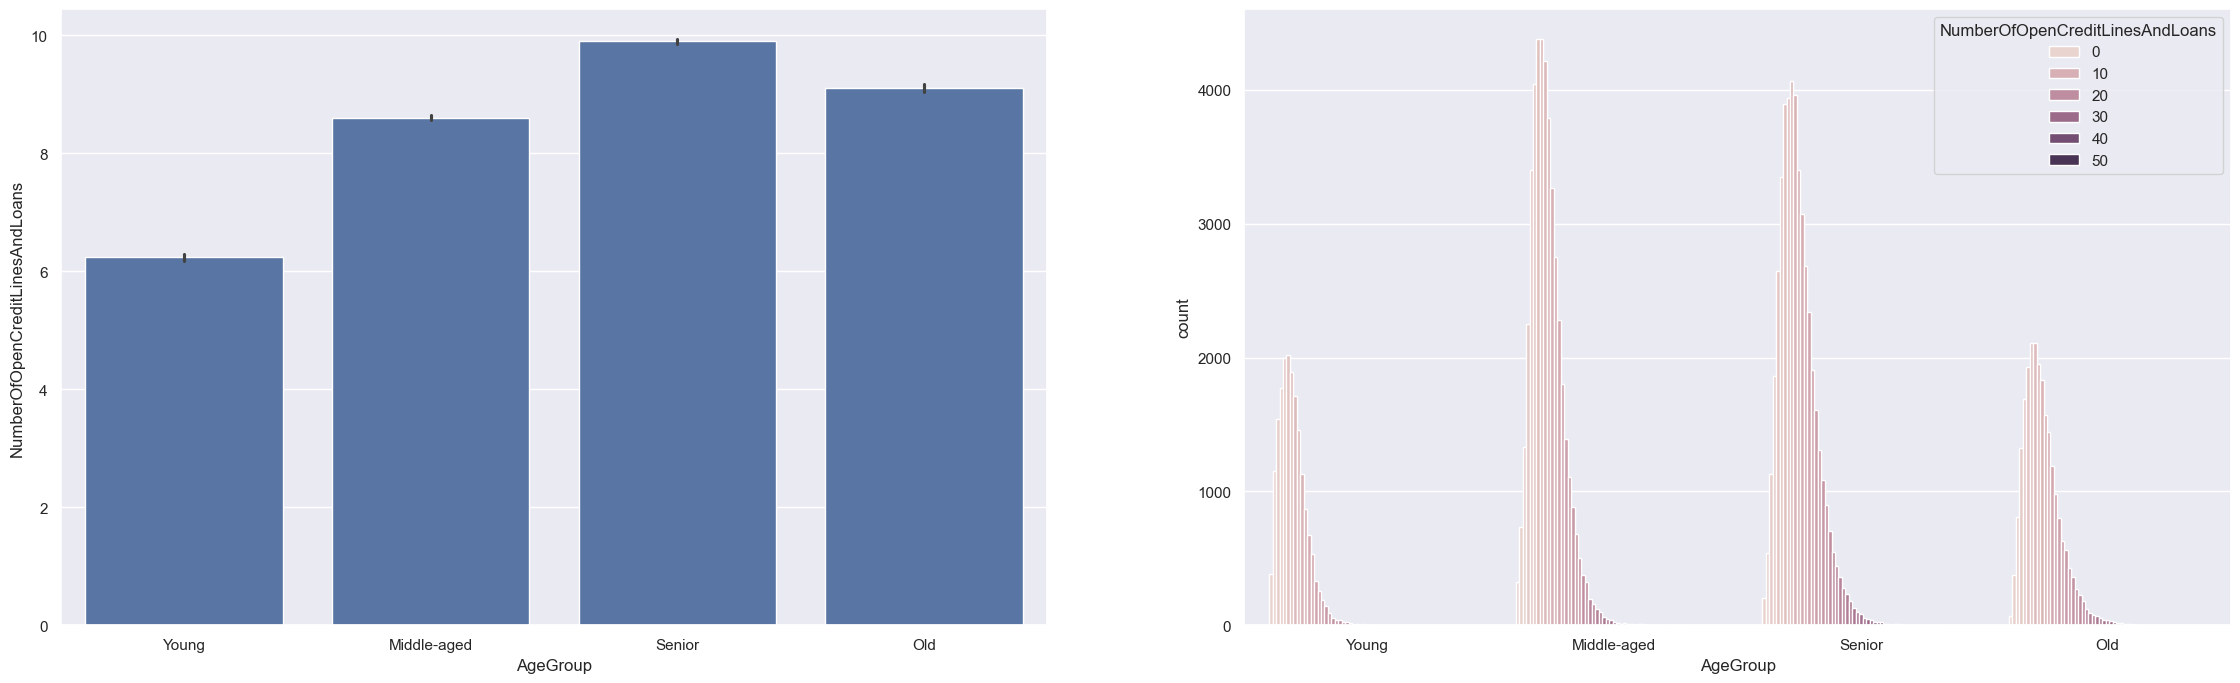

In [27]:
plt.figure(figsize=(28,8))

plt.subplot(1,2,1)
sns.barplot(x='AgeGroup',y='NumberOfOpenCreditLinesAndLoans',data=df)

plt.subplot(1,2,2)
sns.countplot(x='AgeGroup',hue='NumberOfOpenCreditLinesAndLoans',data=df)

<Axes: xlabel='AgeGroup', ylabel='count'>

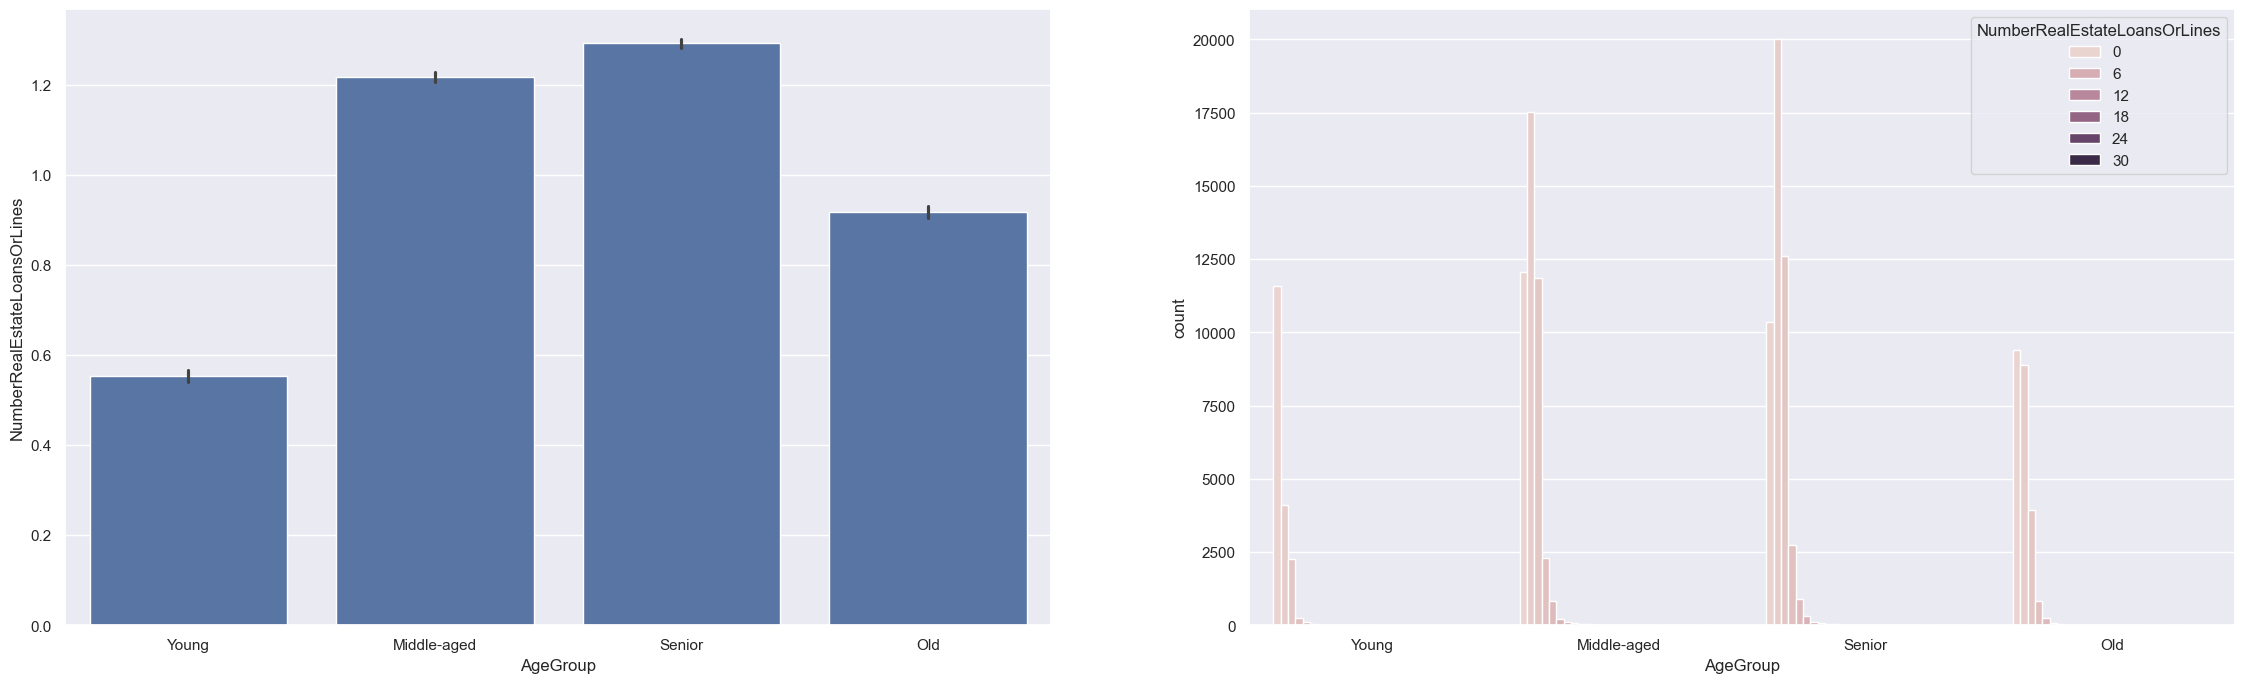

In [28]:
plt.figure(figsize=(28,8))

plt.subplot(1,2,1)
sns.barplot(x='AgeGroup',y='NumberRealEstateLoansOrLines',data=df)

plt.subplot(1,2,2)
sns.countplot(x='AgeGroup',hue='NumberRealEstateLoansOrLines',data=df)

Number of credit lines & loans, and real estate lines & loans increase with age

In [29]:
df.groupby(['90DaysLate','SeriousDlqin2yrs'])['AgeGroup'].value_counts(normalize=True)

90DaysLate  SeriousDlqin2yrs  AgeGroup   
0           0                 Senior         0.356816
                              Middle-aged    0.329331
                              Old            0.184363
                              Young          0.129491
            1                 Middle-aged    0.414489
                              Senior         0.299694
                              Young          0.207785
                              Old            0.078032
1           0                 Middle-aged    0.374270
                              Senior         0.326059
                              Young          0.207562
                              Old            0.092109
            1                 Middle-aged    0.429903
                              Senior         0.277147
                              Young          0.233387
                              Old            0.059562
Name: proportion, dtype: float64

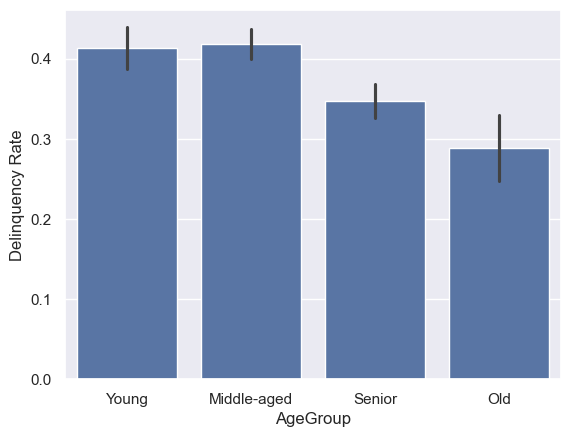

In [30]:
sns.barplot(x='AgeGroup',y='SeriousDlqin2yrs',data=df[df['90DaysLate'] == 1])
plt.ylabel('Delinquency Rate')
plt.show()

**4th observation) Although all age groups' rate are similar, it is the young and middle-aged people who are more likely to deliquent when they are 90 Days Late**

# Income Analysis

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

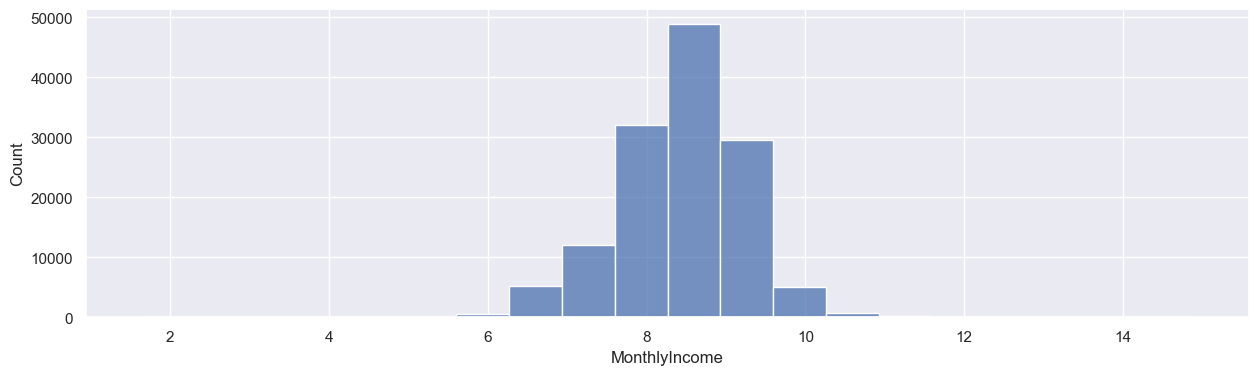

In [31]:
plt.figure(figsize=(15,4))
sns.histplot(np.log(df['MonthlyIncome']),bins=20)

In [32]:
df['Log_Income'] = np.log(df['MonthlyIncome'])

<Axes: xlabel='age', ylabel='Log_Income'>

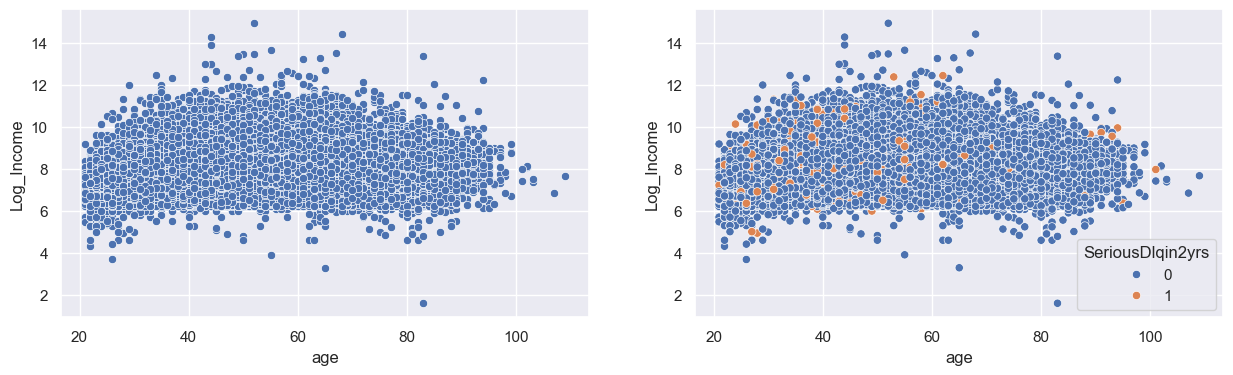

In [33]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
sns.scatterplot(x='age',y='Log_Income',data=df)

plt.subplot(1,2,2)
sns.scatterplot(x='age',y='Log_Income',data=df,hue='SeriousDlqin2yrs')

<Axes: xlabel='Log_Income', ylabel='DebtRatio'>

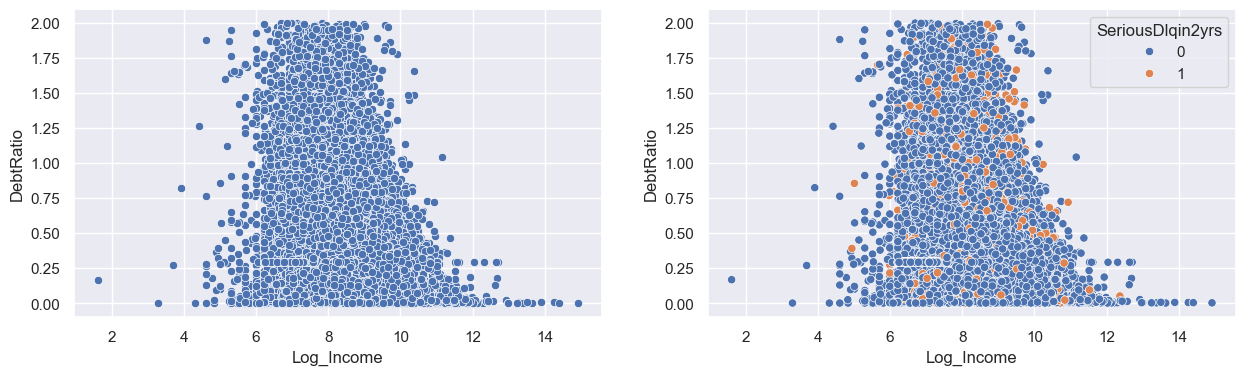

In [34]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
sns.scatterplot(x='Log_Income',y='DebtRatio',data=df)

plt.subplot(1,2,2)
sns.scatterplot(x='Log_Income',y='DebtRatio',data=df,hue='SeriousDlqin2yrs')

No meaningful insight can be drawn from these plots

In [35]:
df.drop(['Log_Income'],axis=1,inplace=True)

# Debt Ratio

<Axes: xlabel='age', ylabel='DebtRatio'>

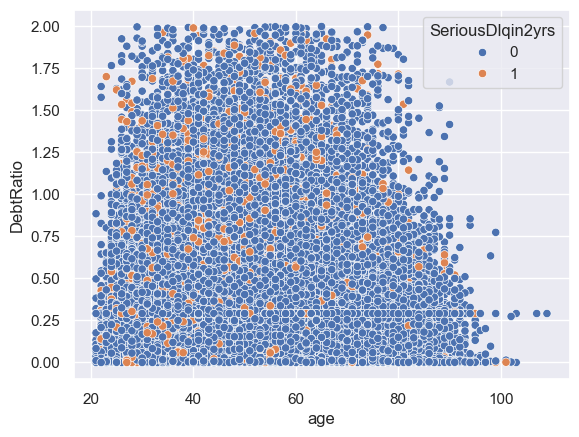

In [36]:
sns.scatterplot(x='age',y='DebtRatio',hue='SeriousDlqin2yrs',data=df)

<Axes: xlabel='SeriousDlqin2yrs', ylabel='DebtRatio'>

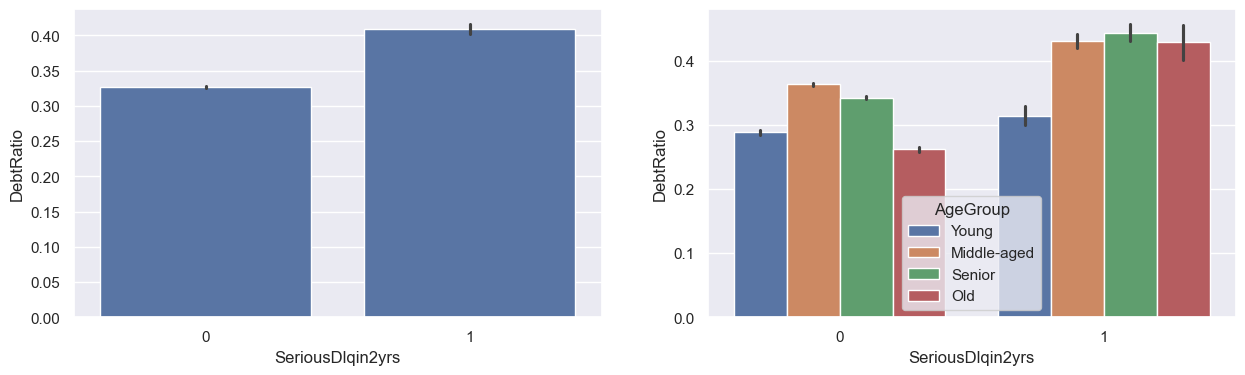

In [37]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
sns.barplot(x='SeriousDlqin2yrs',y='DebtRatio',data=df)

plt.subplot(1,2,2)
sns.barplot(x='SeriousDlqin2yrs',y='DebtRatio',data=df,hue='AgeGroup')

**4th observation) DebtRatio is higher for Serious Deliquents in all age groups**

# Credit Lines and Estate Lines

<Axes: xlabel='NumberOfOpenCreditLinesAndLoans', ylabel='RevolvingUtilizationOfUnsecuredLines'>

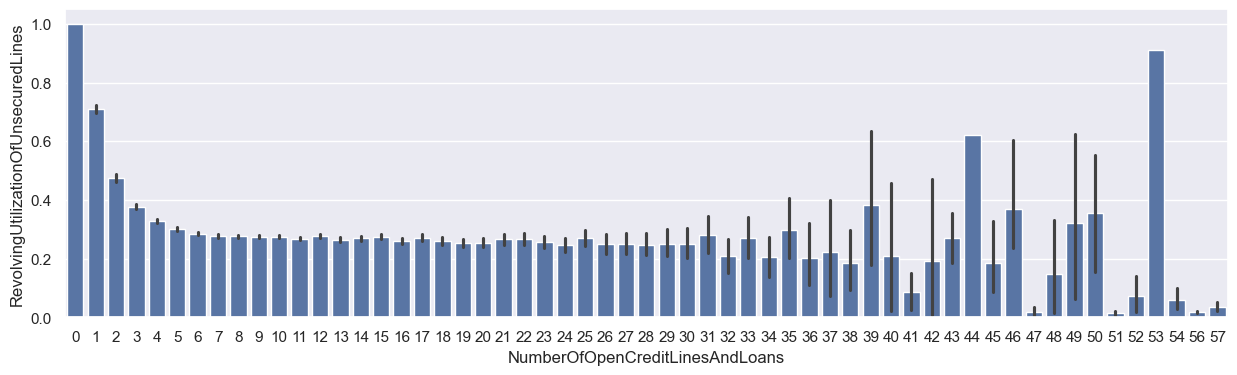

In [38]:
plt.figure(figsize=(15,4))

sns.barplot(x='NumberOfOpenCreditLinesAndLoans',y='RevolvingUtilizationOfUnsecuredLines',data=df)

<Axes: xlabel='NumberRealEstateLoansOrLines', ylabel='RevolvingUtilizationOfUnsecuredLines'>

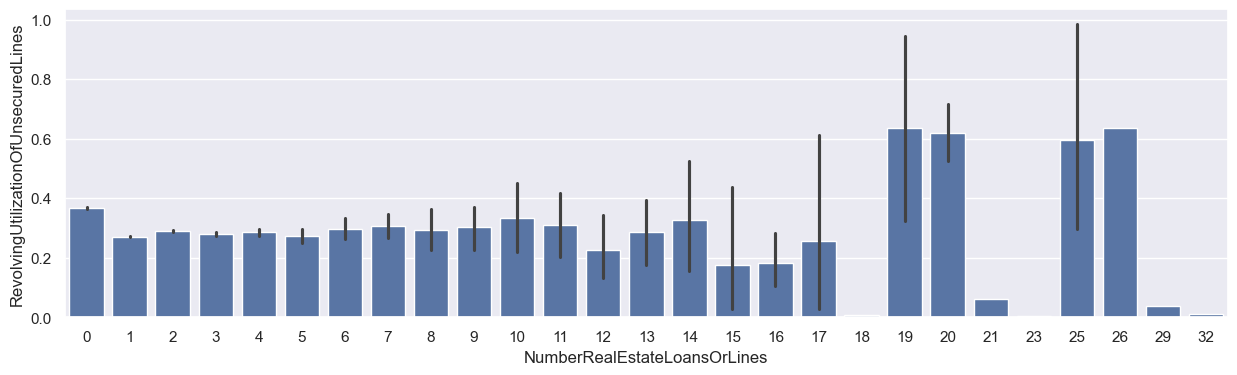

In [39]:
plt.figure(figsize=(15,4))

sns.barplot(x='NumberRealEstateLoansOrLines',y='RevolvingUtilizationOfUnsecuredLines',data=df)

**5th Observation) RevolvingUtilization is highest for people with low number of Credit Lines and Loans, and keeps on decreasing before stabilizing for people with higher number of credit lines**

In [40]:
df['CreditLinesBin'] = pd.cut(df['NumberOfOpenCreditLinesAndLoans'],bins=[-1, 5, 10, 15, 20, 30, 40, 60],
                              labels=['0-5', '6-10', '11-15', '16-20', '21-30', '31-40', '41-60'])

df.groupby('CreditLinesBin', observed=True)['SeriousDlqin2yrs'].mean()

CreditLinesBin
0-5      0.074620
6-10     0.049707
11-15    0.057634
16-20    0.064594
21-30    0.065677
31-40    0.056537
41-60    0.137931
Name: SeriousDlqin2yrs, dtype: float64

In [41]:
df['OpenEstatesBin'] = pd.cut(df['NumberRealEstateLoansOrLines'],bins=[-1, 5, 10, 15, 20, 35],
                              labels=['0-5', '6-10', '11-15', '16-20', '20+'])

df.groupby('OpenEstatesBin', observed=True)['SeriousDlqin2yrs'].mean()

OpenEstatesBin
0-5      0.059164
6-10     0.161290
11-15    0.183333
16-20    0.181818
20+      0.250000
Name: SeriousDlqin2yrs, dtype: float64

In [42]:
df.groupby('OpenEstatesBin',observed=True)['RevolvingUtilizationOfUnsecuredLines'].mean()

OpenEstatesBin
0-5      0.306611
6-10     0.300159
11-15    0.277758
16-20    0.348278
20+      0.317341
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

Revolving Utilization is similar in all Bins

**6th observation)** 

**SeriousDlq rate keeps on increasing as EstateLinesOrLoans increase, while its the approximately the same in CreditLinesBin (except 41-60)**

**Thus, EstateLinesOrLoans matter more than CreditLines when determining Deliquency**

In [43]:
df.drop(['CreditLinesBin','OpenEstatesBin'],axis=1,inplace=True)

# 90DaysLate

In [44]:
Late90days = df[df['90DaysLate']==1]

In [45]:
Late90days.sample()

,age,RevolvingUtilizationOfUnsecuredLines,30-59DaysLate,60-89DaysLate,90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs,AgeGroup
42556,72,0.00019,0,0,1,0.287714,0,4500.0,11,2,0.0,0,Old


<Axes: xlabel='AgeGroup', ylabel='count'>

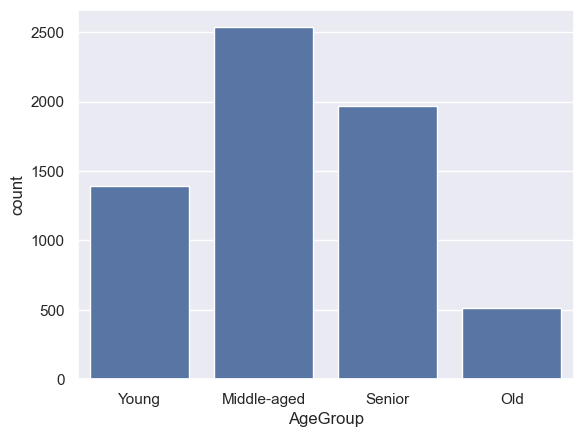

In [46]:
sns.countplot(x='AgeGroup',data=Late90days)

In [47]:
Late90days['Log_Income'] = np.log(Late90days['MonthlyIncome'])

C:\Users\bhavy\AppData\Local\Temp\ipykernel_916\923091801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Late90days['Log_Income'] = np.log(Late90days['MonthlyIncome'])


<Axes: xlabel='Log_Income', ylabel='Count'>

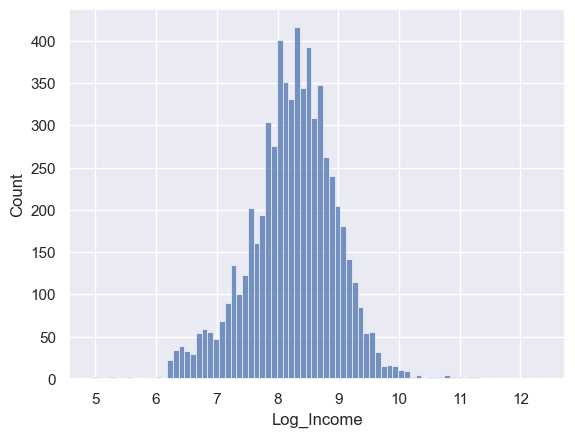

In [48]:
sns.histplot(x='Log_Income',data=Late90days)

Income Distribution is the same for people in this group too.

# Analysis for Serious Deliquents now

In [49]:
Deliquents = df[df['SeriousDlqin2yrs']==1]

In [50]:
Deliquents.sample()

,age,RevolvingUtilizationOfUnsecuredLines,30-59DaysLate,60-89DaysLate,90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs,AgeGroup
57029,42,0.0,0,0,0,0.261737,0,4962.0,3,1,0.0,1,Middle-aged


In [51]:
df.groupby(['SeriousDlqin2yrs'])['RevolvingUtilizationOfUnsecuredLines'].mean()

SeriousDlqin2yrs
0    0.286386
1    0.624291
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

**Serious Deliquents have almost twice the revolving utilization rate**

In [52]:
Deliquents.groupby('AgeGroup')['90DaysLate'].value_counts(normalize=True)

C:\Users\bhavy\AppData\Local\Temp\ipykernel_916\2627165810.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Deliquents.groupby('AgeGroup')['90DaysLate'].value_counts(normalize=True)


AgeGroup     90DaysLate
Young        0             0.666859
             1             0.333141
Middle-aged  0             0.684320
             1             0.315680
Senior       0             0.708564
             1             0.291436
Old          0             0.746552
             1             0.253448
Name: proportion, dtype: float64

90DaysLate proportion is similar in all age groups

<Axes: xlabel='AgeGroup', ylabel='RevolvingUtilizationOfUnsecuredLines'>

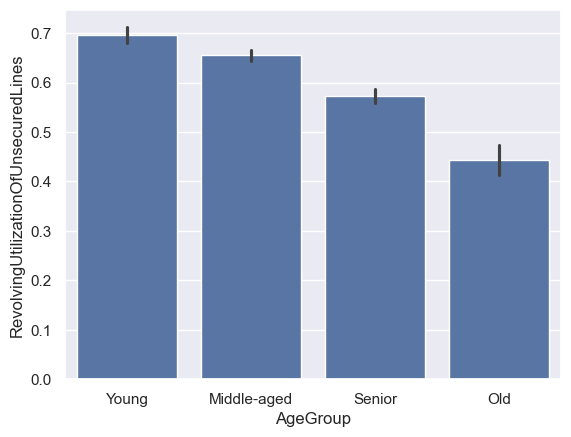

In [53]:
sns.barplot(x='AgeGroup',y='RevolvingUtilizationOfUnsecuredLines',data=Deliquents)

In Serious Deliquents, Revolving Utilization is the highest in Young people, and decreases with age. Its the same as previously seen

# Dependents

<Axes: xlabel='NumberOfDependents', ylabel='RevolvingUtilizationOfUnsecuredLines'>

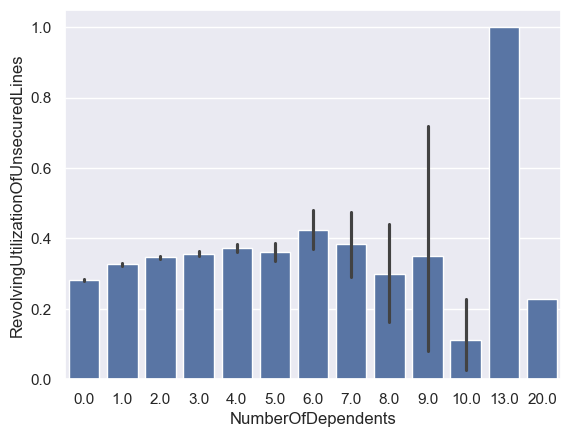

In [54]:
sns.barplot(x='NumberOfDependents',y='RevolvingUtilizationOfUnsecuredLines',data=df)

In [55]:
df[df['NumberOfDependents']>9]['age'].count()

7

The observations for people with number of dependents higher than 9 are based on very few observations. Hence, nothing can be concluded for them

**7th observation) Revolving Utilization increases as number of dependents increase**

<Axes: xlabel='NumberOfDependents', ylabel='RevolvingUtilizationOfUnsecuredLines'>

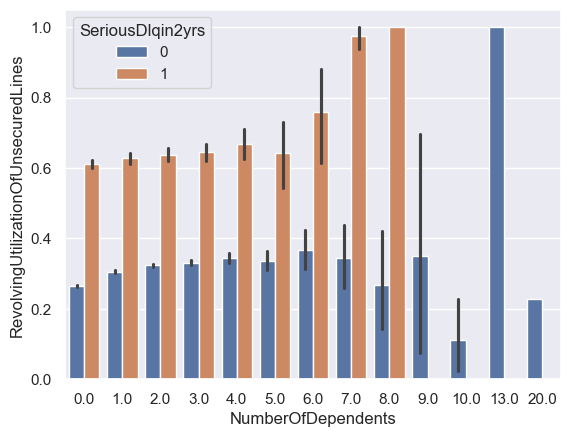

In [56]:
sns.barplot(x='NumberOfDependents',y='RevolvingUtilizationOfUnsecuredLines',data=df,hue='SeriousDlqin2yrs')

**8th Observation) There is a vast difference of Utilization rate among Deliquents and non-deliquents having same number of dependents**

<Axes: xlabel='NumberOfDependents', ylabel='DebtRatio'>

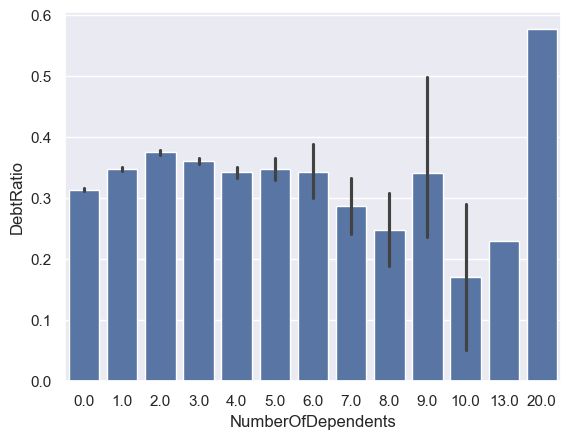

In [57]:
sns.barplot(x='NumberOfDependents',y='DebtRatio',data=df)

Higher number of dependents have 

# Key Insights for Credit Risk

1) Look out for people who have been **late for 90 or more days (Younger and Middle aged people are more likely to be deliquent)**
2) Look out for people having **DebtRatio > 0.4**
3) People having **RevolvingUtilizationOfUnsecuredLines >= 0.5**
4) Revolving Utilization is highest for people with low number of credit lines and estate lines. **People with <=3 credit lines have high Utilization rate (>=0.4)**
5) **Estate lines column is more meaningful than CreditLines** for determining CreditRisk
6) **Revolving utilization increases as number of dependents increase**. This, combined with high utilization rate have higher chance of deliquency

# Target groups

1) People with high Revolving Utilization Rate (>=0.5). (Mainly Young and middle aged people)
2) People who have been late 90+ days with their payment
3) People having DebtRatio > 0.4. Younger people are more likely to Deliquent with a lower DebtRatio
4) People with <=3 Credit Lines, particularly when combined with high utilization rate
5) People with high number of dependents on them and high utilization rate